In [5]:
"""
v7_investment_agent.py
------------------------
NEW USE CASE: Personal Investment Research Assistant.

Why a new use case for this version: the MT599 pipeline (v1-v6) is a FIXED
pipeline -- the steps are always the same, in the same order, regardless of
what's in the message. create_react_agent / ToolNode are for the OPPOSITE
shape of problem: the MODEL decides, at runtime, which tool(s) to call and
in what order, based on the question. Forcing that into the MT599 pipeline
would be artificial. A research assistant that answers free-form questions
about stocks/portfolios is the natural fit -- "what's my portfolio worth"
and "what's happening with NVIDIA" need genuinely different tool calls,
decided by the model, not by a fixed graph shape.

This file demonstrates TWO ways to build the exact same agent, so the
relationship between them is concrete rather than just described:

    PART A -- built BY HAND, using the underlying primitives directly:
              StateGraph + MessagesState + ToolNode + tools_condition.
              This is literally what the convenience wrapper in Part B
              does internally -- seeing it built by hand first makes Part B
              much less "magic."

    PART B -- built with the CURRENT prebuilt convenience wrapper:
              create_agent() from the `langchain` package.

              NAMING NOTE: LangGraph's own reference docs mark
              `create_react_agent` (from langgraph.prebuilt) as DEPRECATED
              in favor of `create_agent` (from langchain.agents), which
              provides the same thing plus a more flexible middleware
              system. Worth knowing BOTH names -- older tutorials, blog
              posts, and even interviewers may still refer to
              "create_react_agent," but current code should use
              create_agent.

Both parts are given the SAME tools and asked the SAME questions, so you
can compare their behavior directly.

Tools (via the `yfinance` library -- free, no API key required):
    - get_stock_price     -- current price + day change for a ticker
    - get_stock_info      -- company name, sector, market cap, 52-week range
    - get_stock_news      -- a few recent headlines for a ticker
    - calculate_portfolio_value -- total value across multiple holdings
"""

import os
from typing import List

from langchain_core.tools import tool
from langchain_together import ChatTogether
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent  # current recommended wrapper

import yfinance as yf


# ---------------------------------------------------------------------------
# 1. TOOLS
#    Each tool is a plain Python function decorated with @tool. The
#    docstring becomes the tool's DESCRIPTION -- this is literal text sent
#    to the LLM to help it decide when to call this tool, so it needs to be
#    clear, not just a comment for humans.
#
#    Every tool wraps its yfinance call in try/except and returns a plain
#    STRING either way (data or an error message) -- tool outputs become
#    ToolMessage content, which the model reads as text. A tool that raises
#    an exception instead of returning text breaks the agent loop; a tool
#    that returns an error STRING lets the model see the problem and decide
#    how to respond (e.g. "I couldn't find data for that ticker").
# ---------------------------------------------------------------------------

@tool
def get_stock_price(ticker: str) -> str:
    """Get the current price and today's percent change for a stock ticker
    (e.g. 'AAPL', 'NVDA', 'MSFT')."""
    try:
        info = yf.Ticker(ticker).info
        price = info.get("currentPrice") or info.get("regularMarketPrice")
        prev_close = info.get("previousClose")
        if price is None:
            return f"Could not find price data for ticker '{ticker}'. Check the symbol is correct."
        change_pct = ((price - prev_close) / prev_close * 100) if prev_close else None
        change_str = f"{change_pct:+.2f}%" if change_pct is not None else "unknown change"
        return f"{ticker.upper()}: ${price:.2f} ({change_str} today)"
    except Exception as e:
        return f"Error fetching price for '{ticker}': {e}"


@tool
def get_stock_info(ticker: str) -> str:
    """Get company name, sector, market cap, and 52-week price range for a
    stock ticker."""
    try:
        info = yf.Ticker(ticker).info
        name = info.get("longName", ticker.upper())
        sector = info.get("sector", "unknown sector")
        market_cap = info.get("marketCap")
        low52 = info.get("fiftyTwoWeekLow")
        high52 = info.get("fiftyTwoWeekHigh")
        market_cap_str = f"${market_cap / 1e9:.1f}B" if market_cap else "unknown"
        return (
            f"{name} ({ticker.upper()}) -- Sector: {sector}. "
            f"Market cap: {market_cap_str}. "
            f"52-week range: ${low52} - ${high52}."
        )
    except Exception as e:
        return f"Error fetching info for '{ticker}': {e}"


@tool
def get_stock_news(ticker: str) -> str:
    """Get a few recent news headlines for a stock ticker."""
    try:
        news_items = yf.Ticker(ticker).news or []
        if not news_items:
            return f"No recent news found for '{ticker}'."
        headlines = []
        for item in news_items[:3]:
            title = item.get("content", {}).get("title") or item.get("title")
            if title:
                headlines.append(f"- {title}")
        return f"Recent headlines for {ticker.upper()}:\n" + "\n".join(headlines) if headlines \
            else f"No recent news found for '{ticker}'."
    except Exception as e:
        return f"Error fetching news for '{ticker}': {e}"


@tool
def calculate_portfolio_value(tickers: List[str], shares: List[int]) -> str:
    """Calculate the total current value of a portfolio. `tickers` and
    `shares` are parallel lists -- e.g. tickers=['AAPL','MSFT'],
    shares=[10, 5] means 10 shares of AAPL and 5 shares of MSFT."""
    if len(tickers) != len(shares):
        return "Error: tickers and shares lists must be the same length."

    lines = []
    total = 0.0
    for ticker, share_count in zip(tickers, shares):
        try:
            info = yf.Ticker(ticker).info
            price = info.get("currentPrice") or info.get("regularMarketPrice")
            if price is None:
                lines.append(f"{ticker.upper()}: price unavailable, skipped")
                continue
            value = price * share_count
            total += value
            lines.append(f"{ticker.upper()}: {share_count} shares x ${price:.2f} = ${value:,.2f}")
        except Exception as e:
            lines.append(f"{ticker.upper()}: error ({e}), skipped")

    lines.append(f"TOTAL PORTFOLIO VALUE: ${total:,.2f}")
    return "\n".join(lines)


TOOLS = [get_stock_price, get_stock_info, get_stock_news, calculate_portfolio_value]


In [3]:
#%pip install yfinance

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.0 MB/s  0:00:00

   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [pytz]
   ---- -----------------------------------  1/10 [peewee]
   ---- -----------------------------------  1/10 [peewee]
   ------------ ---------------------------  3/10 [soupsieve]
   -------------------- -------------------  5/10 [protobuf]
   -------------------- -------------------  5/10 [protobuf]
   -------------------- -------------------  5/10 [protobuf]
   ------------------------ ---------------  6/10 [cffi]
   ------------------------ ---------------  6/10 [cffi]
   

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [7]:
from dotenv import load_dotenv
load_dotenv(".env")
# ---------------------------------------------------------------------------
# 2. LLM SETUP
# ---------------------------------------------------------------------------

TOGETHER_MODEL = "Qwen/Qwen2.5-7B-Instruct-Turbo"

llm = ChatTogether(
    model=TOGETHER_MODEL,
    temperature=0,
    together_api_key=os.getenv("TOGETHER_API_KEY"),
)

SYSTEM_PROMPT = (
    "You are a helpful personal investment research assistant. "
    "Use the available tools to answer questions about stock prices, "
    "company info, recent news, and portfolio value. "
    "Always use a tool to get real data rather than guessing numbers. "
    "Be concise and clear -- this is for an individual managing their own "
    "investments, not a financial report."
)

In [9]:

# ---------------------------------------------------------------------------
# 3. PART A -- BUILT BY HAND with the underlying primitives
#
#    MessagesState: a prebuilt state schema (just {"messages": [...]}) that
#    already has the right reducer (add_messages) wired in -- new messages
#    APPEND to the list rather than replacing it, and messages with matching
#    IDs get updated in place instead of duplicated. This is the standard
#    state shape for any chat/tool-calling agent, so LangGraph ships it
#    rather than making everyone redefine it themselves.
#
#    tools_condition: a PREBUILT decision function (from langgraph.prebuilt)
#    -- equivalent in spirit to the route_by_type()-style functions you
#    wrote by hand in the MT599 pipeline, except this one specifically
#    checks: "does the last message contain tool_calls?" If yes, route to
#    the node named "tools". If no, route to END. You could write this
#    yourself in about 4 lines -- it's provided because EVERY tool-calling
#    agent needs the exact same check.
# ---------------------------------------------------------------------------

llm_with_tools = llm.bind_tools(TOOLS)


def call_model(state: MessagesState) -> dict:
    """
    The 'reasoning' half of the ReAct loop: the model looks at the full
    message history so far and either answers directly, or emits one or
    more tool_calls asking for more information.
    """
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


manual_builder = StateGraph(MessagesState)
manual_builder.add_node("call_model", call_model)
manual_builder.add_node("tools", ToolNode(TOOLS))  # executes whichever tool(s) the model asked for

manual_builder.add_edge(START, "call_model")

# tools_condition inspects the last message in state["messages"]:
#   - if it has tool_calls -> returns "tools"
#   - otherwise            -> returns END
# No explicit mapping dict needed -- the strings it returns already match
# node names ("tools") or the graph's built-in END marker.
manual_builder.add_conditional_edges("call_model", tools_condition)

# After the tools run, go BACK to call_model -- this is the loop. The model
# now sees the tool's result (as a ToolMessage) and decides whether it has
# enough information to answer, or needs to call another tool.
manual_builder.add_edge("tools", "call_model")

manual_agent = manual_builder.compile(checkpointer=InMemorySaver())



In [11]:

# ---------------------------------------------------------------------------
# 4. PART B -- PREBUILT convenience wrapper
#
#    create_agent() builds EXACTLY the graph shape above (agent node <->
#    tools node, looping until no more tool_calls) in one call. It also
#    accepts a `system_prompt`, prepended as a SystemMessage automatically
#    -- Part A didn't have a system prompt at all, so Part B's agent should
#    behave a bit more consistently/on-topic by comparison.
# ---------------------------------------------------------------------------

prebuilt_agent = create_agent(
    model=llm,
    tools=TOOLS,
    system_prompt=SYSTEM_PROMPT,
    checkpointer=InMemorySaver(),
)

In [13]:

# ---------------------------------------------------------------------------
# 5. VISUALIZE BOTH GRAPHS
#    Worth comparing side by side -- they should look structurally
#    identical (an agent/call_model node looping with a tools node), since
#    that's the actual claim being demonstrated in this file.
# ---------------------------------------------------------------------------

def visualize_graph(compiled_graph, output_path: str) -> None:
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
    except Exception as e:
        print(f"Graph visualization failed (mermaid/graphviz dependency issue?): {e}")
        return

    try:
        from IPython.display import Image, display
        from IPython import get_ipython
        if get_ipython() is not None:
            display(Image(png_bytes))
            return
    except ImportError:
        pass

    with open(output_path, "wb") as f:
        f.write(png_bytes)
    print(f"Graph diagram saved to: {output_path}")


Visualizing Part A (hand-built) graph:


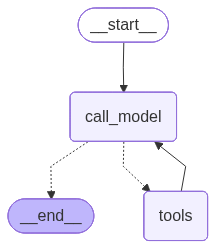


Visualizing Part B (prebuilt) graph:


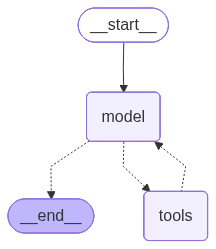


QUESTION: What's the current price of NVIDIA stock, and how has it moved today?

--- Part A (hand-built ReAct loop) ---
The current price of NVIDIA stock (ticker: NVDA) is $194.83. It has moved down by 1.39% today.

--- Part B (create_agent prebuilt) ---
The current price of NVIDIA (NVDA) stock is $194.83. It has moved down by 1.39% today.

QUESTION: I own 10 shares of AAPL and 5 shares of MSFT. What's my portfolio worth right now?

--- Part A (hand-built ReAct loop) ---
Based on the current share prices, your portfolio is worth $5,038.75. Here's the breakdown:

- Apple (AAPL): 10 shares x $308.63 = $3,086.30
- Microsoft (MSFT): 5 shares x $390.49 = $1,952.45

So, the total portfolio value is $5,038.75. Please note that these values are based on the share prices at the time of the query and can fluctuate due to market changes.

--- Part B (create_agent prebuilt) ---
Based on the current share prices, your portfolio is worth $5,038.75. Here's the breakdown:
- Apple (AAPL): 10 shares x 

In [15]:

# ---------------------------------------------------------------------------
# 6. QUICK TEST -- ask both agents the same questions
# ---------------------------------------------------------------------------

QUESTIONS = [
    "What's the current price of NVIDIA stock, and how has it moved today?",
    "I own 10 shares of AAPL and 5 shares of MSFT. What's my portfolio worth right now?",
    "What's the latest news on Tesla?",
]


def ask(agent, question: str, thread_id: str) -> str:
    config = {"configurable": {"thread_id": thread_id}}
    result = agent.invoke({"messages": [{"role": "user", "content": question}]}, config)
    return result["messages"][-1].content


if __name__ == "__main__":
    print("Visualizing Part A (hand-built) graph:")
    visualize_graph(manual_agent, "graph_v7_manual.png")

    print("\nVisualizing Part B (prebuilt) graph:")
    visualize_graph(prebuilt_agent, "graph_v7_prebuilt.png")

    for i, question in enumerate(QUESTIONS):
        print("\n" + "=" * 70)
        print(f"QUESTION: {question}")
        print("=" * 70)

        print("\n--- Part A (hand-built ReAct loop) ---")
        print(ask(manual_agent, question, thread_id=f"manual-{i}"))

        print("\n--- Part B (create_agent prebuilt) ---")
        print(ask(prebuilt_agent, question, thread_id=f"prebuilt-{i}"))
